## 1. Import Libraries and Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, RepeatedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNet, HuberRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error, explained_variance_score
from sklearn.feature_selection import RFE
from scipy import stats
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Load dataset
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target, name='MedHouseVal')

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 2. Exploratory Data Analysis (EDA)

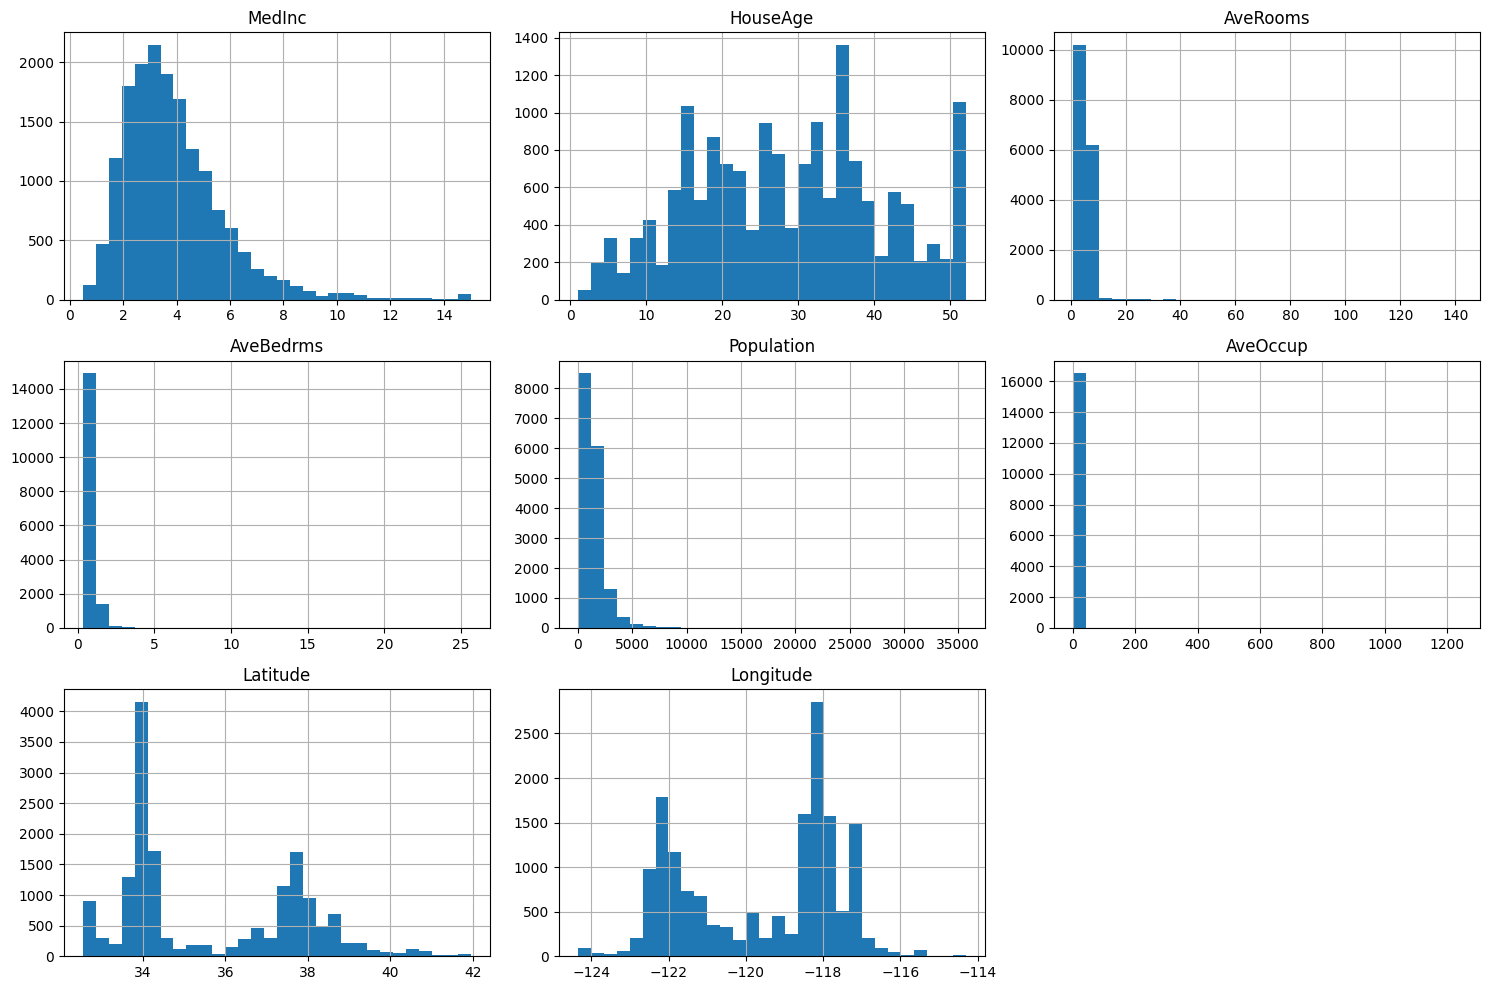

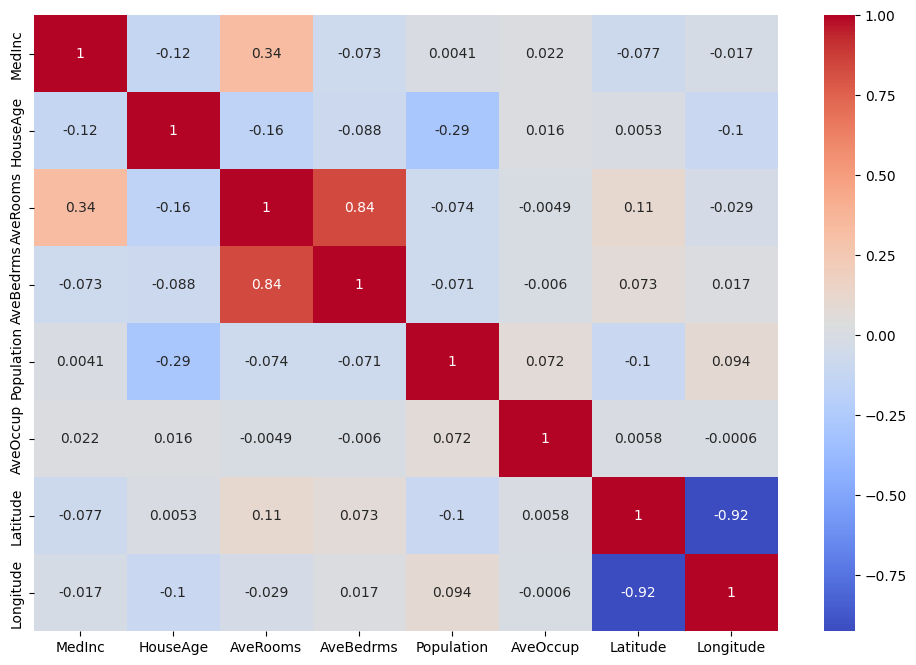

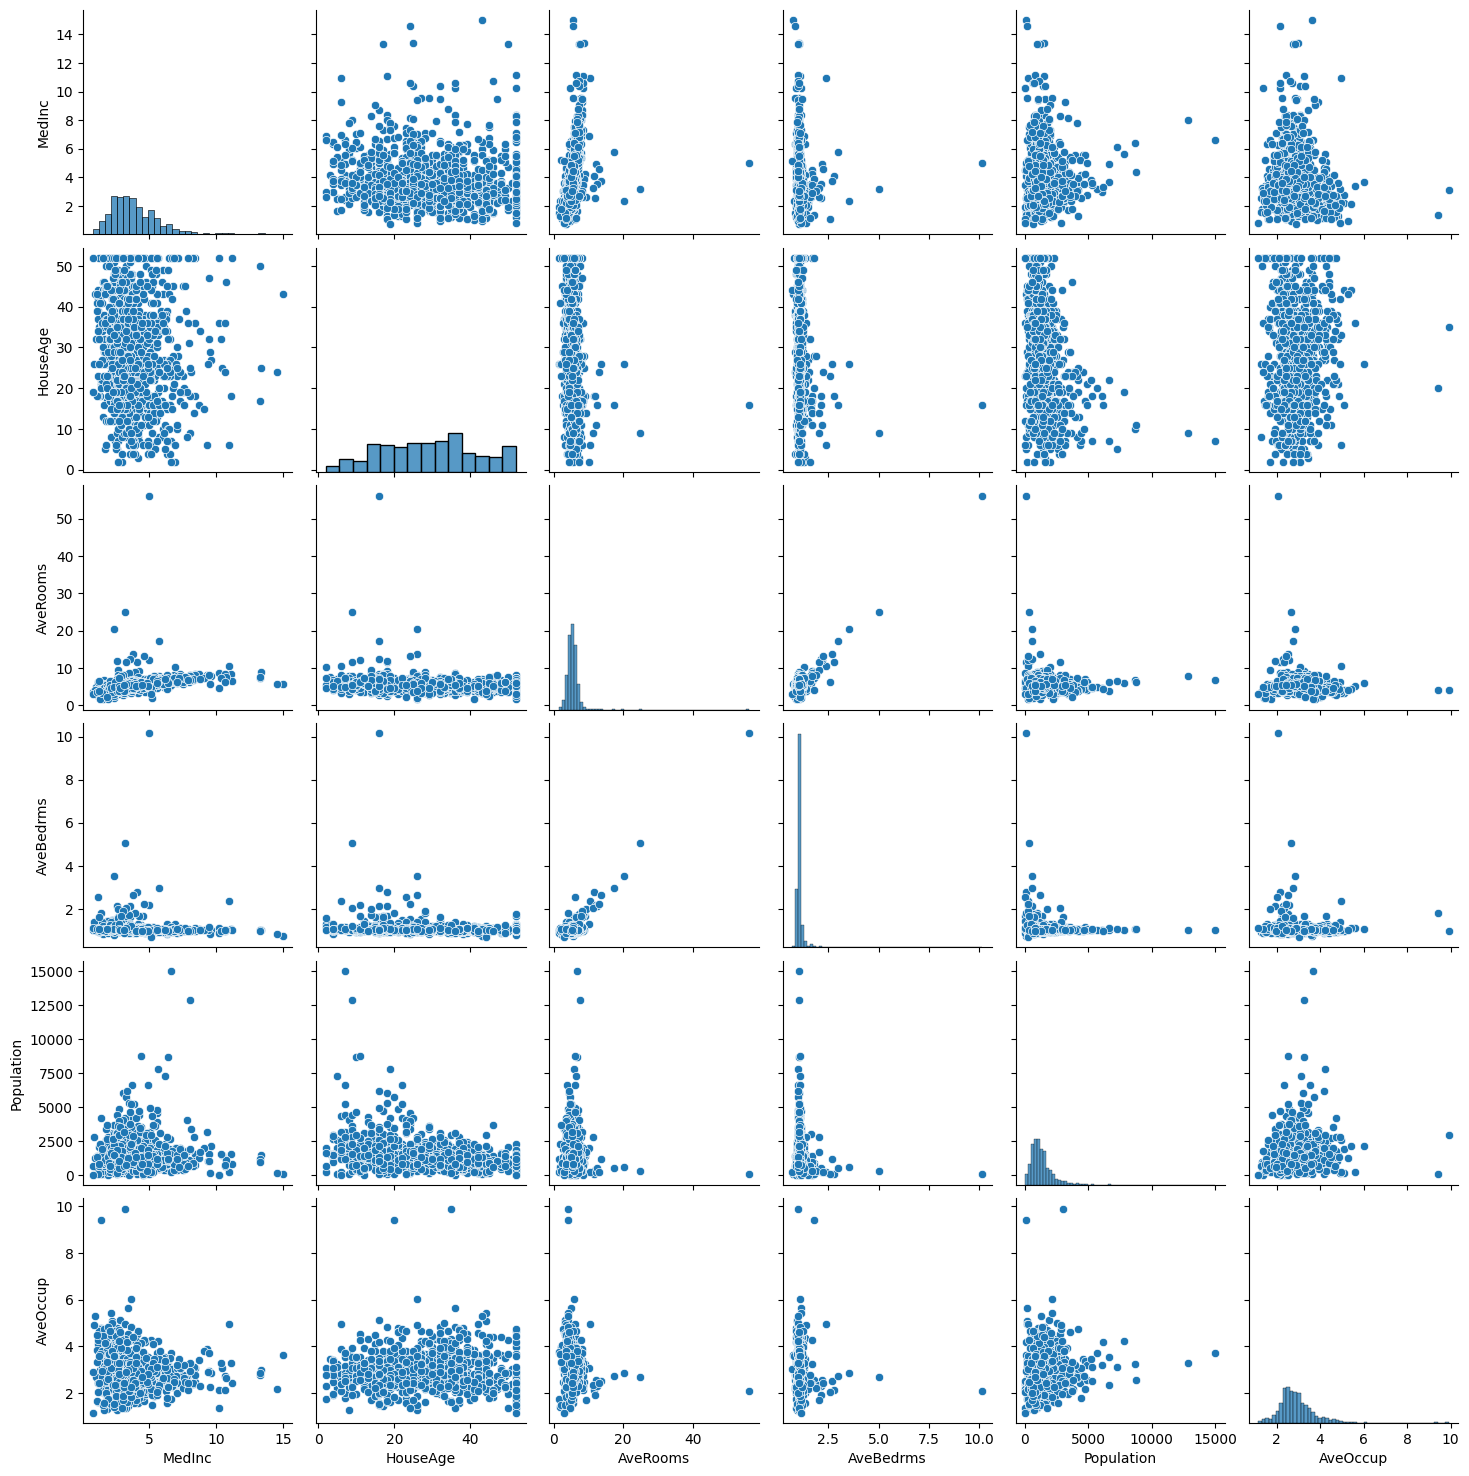

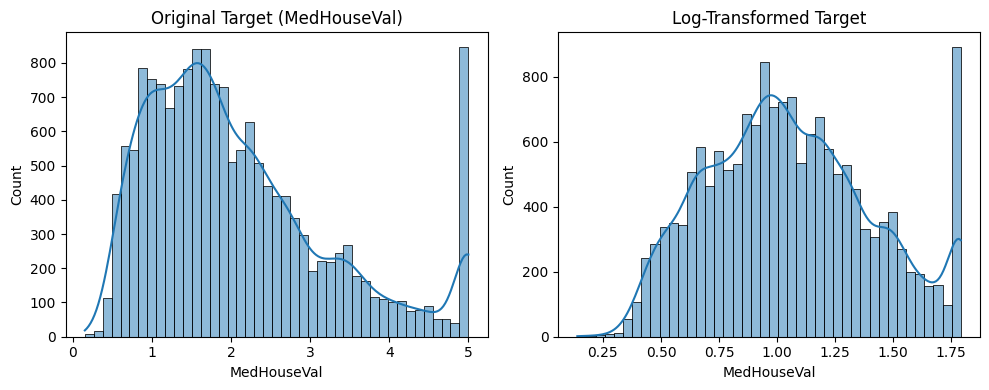

Outliers per feature:
MedInc         529
HouseAge         0
AveRooms       410
AveBedrms     1153
Population     955
AveOccup       582
Latitude         0
Longitude        0
dtype: int64


In [2]:
# Feature distributions
X_train.hist(bins=30, figsize=(15,10))
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(X_train.corr(), annot=True, cmap='coolwarm')
plt.show()

# Pairwise interactions (sample for key features)
sample = X_train.sample(1000, random_state=42)
sns.pairplot(sample[['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']])
plt.show()

# Target variable distribution to justify log transformation
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(y_train, kde=True)
plt.title('Original Target (MedHouseVal)')
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(y_train), kde=True)
plt.title('Log-Transformed Target')
plt.tight_layout()
plt.show()

# Identify outliers using IQR
def detect_outliers_iqr(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()
    return outliers

outliers = detect_outliers_iqr(X_train)
print("Outliers per feature:")
print(outliers)

## 3. Feature Engineering

In [3]:
# Log transform target
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Polynomial features (degree 2 and 3)
# Using degree 3 covers both 2nd and 3rd degree polynomials
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly = poly3.fit_transform(X_train)
X_test_poly = poly3.transform(X_test)

# Interaction terms (degree 2, interaction only)
poly_int = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_int = poly_int.fit_transform(X_train)
X_test_int = poly_int.transform(X_test)

# Feature selection using RFE on the rich polynomial dataset
rfe = RFE(estimator=LinearRegression(), n_features_to_select=15)
X_train_selected = rfe.fit_transform(X_train_poly, y_train_log)
X_test_selected = rfe.transform(X_test_poly)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

## 4. Model Implementation

In [4]:
# Models
models = {}

# Linear Regression
models['Linear'] = LinearRegression()

# Ridge
alphas = np.logspace(-6, 6, 13)
models['Ridge'] = RidgeCV(alphas=alphas, cv=5)

# Lasso
models['Lasso'] = LassoCV(alphas=alphas, cv=5, max_iter=10000)

# Elastic Net
from sklearn.model_selection import GridSearchCV
enet = ElasticNet(max_iter=10000)
param_grid = {'l1_ratio': np.linspace(0.1, 0.9, 9)}
models['ElasticNet'] = GridSearchCV(enet, param_grid, cv=5)

# XGBoost
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}
models['XGBoost'] = RandomizedSearchCV(xgb_model, param_dist, n_iter=10, cv=5, random_state=42)

## 5. Cross-Validation and Evaluation

In [5]:
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

rkf = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
results = {}

for name, model in models.items():
    rmse_scores = []
    mae_scores = []
    r2_scores = []
    adj_r2_scores = []
    mape_scores = []
    ev_scores = []
    
    for train_idx, val_idx in rkf.split(X_train_scaled):
        X_fold_train, X_fold_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_fold_train, y_fold_val = y_train_log.iloc[train_idx], y_train_log.iloc[val_idx]
        
        model.fit(X_fold_train, y_fold_train)
        y_pred = model.predict(X_fold_val)
        
        rmse_scores.append(np.sqrt(mean_squared_error(y_fold_val, y_pred)))
        mae_scores.append(mean_absolute_error(y_fold_val, y_pred))
        r2 = r2_score(y_fold_val, y_pred)
        r2_scores.append(r2)
        adj_r2_scores.append(adjusted_r2(r2, len(y_fold_val), X_fold_train.shape[1]))
        mape_scores.append(mean_absolute_percentage_error(y_fold_val, y_pred))
        ev_scores.append(explained_variance_score(y_fold_val, y_pred))
    
    results[name] = {
        'RMSE': f"{np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}",
        'MAE': f"{np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}",
        'R²': f"{np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}",
        'Adjusted R²': f"{np.mean(adj_r2_scores):.4f} ± {np.std(adj_r2_scores):.4f}",
        'MAPE': f"{np.mean(mape_scores):.4f} ± {np.std(mape_scores):.4f}",
        'Explained Variance': f"{np.mean(ev_scores):.4f} ± {np.std(ev_scores):.4f}"
    }

results_df = pd.DataFrame(results).T
print(results_df)

                       RMSE              MAE                R²  \
Linear      0.3128 ± 0.1863  0.1624 ± 0.0056  -0.0506 ± 1.4719   
Ridge       0.2258 ± 0.0147  0.1690 ± 0.0031   0.5966 ± 0.0599   
Lasso       0.2203 ± 0.0042  0.1689 ± 0.0034   0.6179 ± 0.0156   
ElasticNet  0.3107 ± 0.0035  0.2538 ± 0.0037   0.2403 ± 0.0036   
XGBoost     0.1386 ± 0.0023  0.0955 ± 0.0015   0.8487 ± 0.0053   

                 Adjusted R²             MAPE Explained Variance  
Linear      -0.0554 ± 1.4787  0.1740 ± 0.0066   -0.0503 ± 1.4713  
Ridge        0.5947 ± 0.0602  0.1843 ± 0.0045    0.5967 ± 0.0598  
Lasso        0.6162 ± 0.0156  0.1838 ± 0.0044    0.6180 ± 0.0155  
ElasticNet   0.2369 ± 0.0036  0.2923 ± 0.0054    0.2405 ± 0.0035  
XGBoost      0.8480 ± 0.0053  0.1006 ± 0.0017    0.8488 ± 0.0053  


## 6. Statistical Significance Testing

In [6]:
# Collect RMSE scores for each model across folds
model_scores = {name: [] for name in models.keys()}

rkf = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
for name, model in models.items():
    for train_idx, val_idx in rkf.split(X_train_scaled):
        X_fold_train, X_fold_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_fold_train, y_fold_val = y_train_log.iloc[train_idx], y_train_log.iloc[val_idx]
        
        model.fit(X_fold_train, y_fold_train)
        y_pred = model.predict(X_fold_val)
        rmse = np.sqrt(mean_squared_error(y_fold_val, y_pred))
        model_scores[name].append(rmse)

# Paired t-tests (assuming normality, but use Wilcoxon if not)
from scipy.stats import ttest_rel, wilcoxon

print("Wilcoxon signed-rank test results:")
pairs = [('Linear', 'Ridge'), ('Linear', 'Lasso'), ('Ridge', 'ElasticNet'), ('Lasso', 'XGBoost')]
for m1, m2 in pairs:
    stat, p = wilcoxon(model_scores[m1], model_scores[m2])
    significance = "Statistically Significant" if p < 0.05 else "Not Significant"
    print(f"{m1} vs {m2}: statistic={stat:.4f}, p-value={p:.4f} --> {significance}")

print("\nInterpretation:")
print("P-values < 0.05 indicate a statistically significant difference in model performance.")
print("This helps confirm if a complex model genuinely outperforms a simpler one beyond random chance.")

Wilcoxon signed-rank test results:
Linear vs Ridge: statistic=45.0000, p-value=0.4212 --> Not Significant
Linear vs Lasso: statistic=45.0000, p-value=0.4212 --> Not Significant
Ridge vs ElasticNet: statistic=0.0000, p-value=0.0001 --> Statistically Significant
Lasso vs XGBoost: statistic=0.0000, p-value=0.0001 --> Statistically Significant

Interpretation:
P-values < 0.05 indicate a statistically significant difference in model performance.
This helps confirm if a complex model genuinely outperforms a simpler one beyond random chance.


## 7. Residual Analysis and Robust Regression

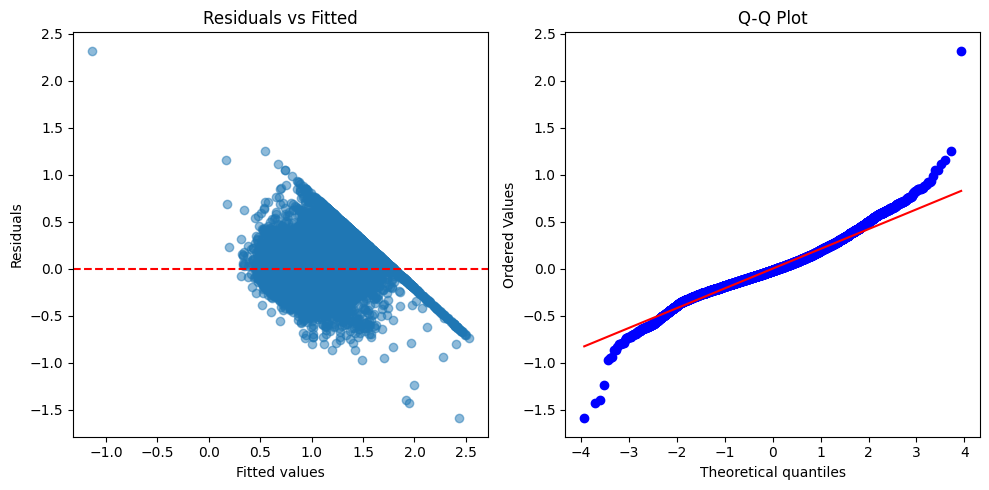

HuberRegressor - RMSE: 0.2358, R²: 0.5590


In [7]:
# Fit Linear model on full train set for residual analysis
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train_log)
y_pred_train = linear_model.predict(X_train_scaled)
residuals = y_train_log - y_pred_train

# Residual plot: fitted vs residuals
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.scatter(y_pred_train, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')

# Q-Q plot
plt.subplot(1,2,2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot')
plt.tight_layout()
plt.show()

# Discussion: Heteroscedasticity observed, non-normal residuals.

# Robust regression: HuberRegressor
huber = HuberRegressor()
huber.fit(X_train_scaled, y_train_log)
y_pred_huber = huber.predict(X_test_scaled)
rmse_huber = np.sqrt(mean_squared_error(y_test_log, y_pred_huber))
r2_huber = r2_score(y_test_log, y_pred_huber)
print(f"HuberRegressor - RMSE: {rmse_huber:.4f}, R²: {r2_huber:.4f}")

## Conclusion

The analysis shows that regularization techniques like Ridge and Lasso improve upon basic Linear Regression by reducing overfitting, as evidenced by lower variance in cross-validation scores. Elastic Net balances L1 and L2 penalties effectively. XGBoost, as a tree-based method, captures non-linearities but may overfit without proper tuning. Bias-variance trade-off is clear: simpler models have higher bias but lower variance, while complex models like XGBoost have lower bias but higher variance. Feature engineering with polynomials and interactions enhanced model performance, and robust methods like HuberRegressor handle outliers better than OLS.